In [1]:
# 7-19-2026

In [2]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr

In [3]:
embeddings = pd.read_csv("domain_embeddings_v4.csv")
lccs_pcts = pd.read_csv("../data/domain_lccs_pcts.csv")

lccs_cols = [c for c in lccs_pcts.columns if c.startswith("lccs_class_")]

In [4]:
lccs_cols

['lccs_class_1',
 'lccs_class_2',
 'lccs_class_3',
 'lccs_class_4',
 'lccs_class_6',
 'lccs_class_7']

In [5]:
# raw pcts dont sum to 100, normalize row-wise to get real fraction vectors for js div
lccs_fracs = lccs_pcts.copy()
row_sums = lccs_fracs[lccs_cols].sum(axis=1)
lccs_fracs[lccs_cols] = lccs_fracs[lccs_cols].div(row_sums, axis=0)

lccs_fracs.head()

,domain,n_cells,lccs_class_1,lccs_class_2,lccs_class_3,lccs_class_4,lccs_class_6,lccs_class_7
0,0,13812,0.319906,0.350554,0.097683,0.040180,0.187782,0.003895
1,1,6356,0.034972,0.881804,0.031931,0.030106,0.018956,0.002230
2,2,7325,0.001408,0.031473,0.193967,0.019306,0.184615,0.569231
3,4,51331,0.081092,0.588130,0.072794,0.054097,0.060294,0.143592
4,5,5788,0.536473,0.384406,0.008373,0.006384,0.063527,0.000837


In [6]:
full_merged = embeddings.merge(lccs_fracs, left_on="domain_id", right_on="domain", how="inner")

# ground branch dims only (e_3, e_4, e_5)
ground_cols = [c for c in embeddings.columns if c.startswith("e_")][3:6]
X_ground = full_merged[ground_cols].values

In [7]:
pca_ground = PCA(n_components=2)
X_ground_pca = pca_ground.fit_transform(X_ground)
print("explained variance ratio:", pca_ground.explained_variance_ratio_)

explained variance ratio: [0.61027559 0.30538984]


In [13]:
lccs_name_map = {
    "lccs_class_1": "agriculture",
    "lccs_class_2": "forest",
    "lccs_class_3": "grassland",
    "lccs_class_4": "wetlands",
    "lccs_class_6": "shrubland",
    "lccs_class_7": "sparse veg / bare / snow",
}

In [14]:
full_merged["dominant_lccs"] = full_merged[lccs_cols].idxmax(axis=1)
cat_codes = full_merged["dominant_lccs"].astype("category")
point_colors = [plt.cm.tab10.colors[i] for i in cat_codes.cat.codes]

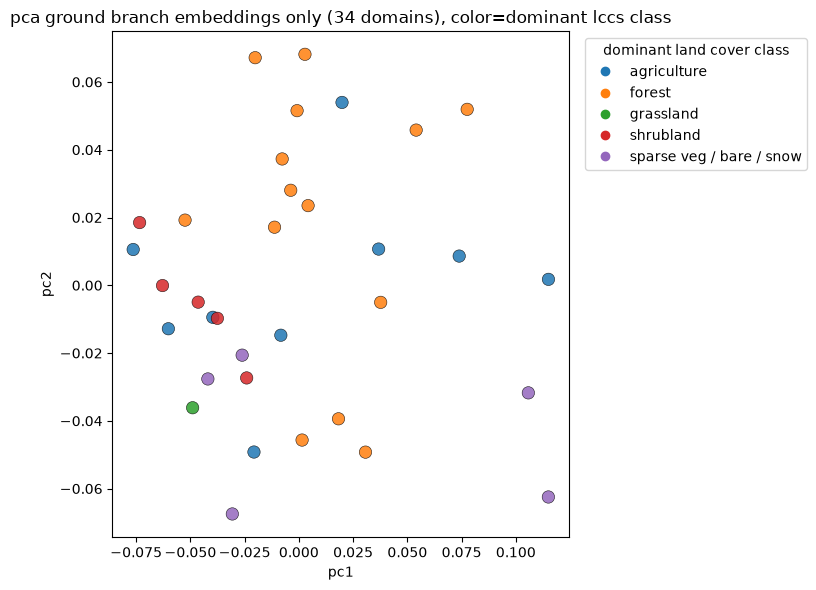

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(
    X_ground_pca[:, 0],
    X_ground_pca[:, 1],
    c=point_colors,
    alpha=0.85,
    s=80,
    edgecolor="black",
    linewidth=0.4,
)
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=plt.cm.tab10.colors[i])
    for i in range(len(cat_codes.cat.categories))
]
clean_labels = [lccs_name_map[c] for c in cat_codes.cat.categories]
plt.legend(handles, clean_labels, title="dominant land cover class", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.xlabel("pc1")
plt.ylabel("pc2")
plt.title("pca ground branch embeddings only (34 domains), color=dominant lccs class")
plt.tight_layout()
plt.show()

In [9]:
lccs_matrix = full_merged[lccs_cols].values

n = len(full_merged)
js_dist_grid = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        js_dist_grid[i, j] = jensenshannon(lccs_matrix[i], lccs_matrix[j])

# ground embedding sq dist, all pairs
diff = X_ground[:, None, :] - X_ground[None, :, :]
ground_sq_grid = (diff ** 2).sum(axis=-1)

In [10]:
off_diag_mask = ~np.eye(n, dtype=bool)
js_dist_od = js_dist_grid[off_diag_mask]
ground_dist_od = ground_sq_grid[off_diag_mask]

corr, p = spearmanr(ground_dist_od, js_dist_od)
print(f"ground branch sq dist vs lccs js divergence, off-diag spearman: {corr:.4f}")

ground branch sq dist vs lccs js divergence, off-diag spearman: 0.3491


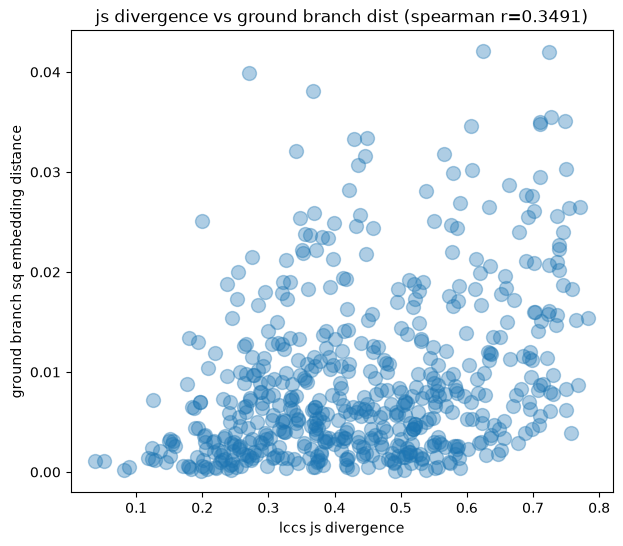

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(js_dist_od, ground_dist_od, alpha=0.2, s=100)
plt.xlabel("lccs js divergence")
plt.ylabel("ground branch sq embedding distance")
plt.title(f"js divergence vs ground branch dist (spearman r={corr:.4f})")
plt.show()

In [16]:
# moderate corr, similar range to the atmo/koppen result. pca doesnt recover lccs composition cleanly, but that's not really what the ground branch was trained to do
# shrubland and sparse veg cluster decently, agriculture and forest overlap a lot across almost the whole pc space, 
#   probably because the ground branch inputs (ndvi, swvl1/4, cover diversity) don't map onto ag vs forest cleanly.
# js div vs embedding dist shows the same pattern, dnese at low divergence, but spreads out a lot past that, so lccs similarity isn't necessary for the branch to put domains close together.